# 00 — E-Val-1: Warmup Validation & Measurement Honesty Gate

> **SHAKEDOWN-MACOS — INFORMATIONAL ONLY.** Numbers below are from macOS
> Apple Silicon shakedown runs. They confirm the measurement rig is honest;
> they are NOT thesis-grade and must not be cited as canonical results.

RFC-008 §E-Val-1. Injects a known 50 ms delay via a `delay-injector` Wasm
plugin and verifies the measurement harness recovers it within a [45, 55] ms
honesty gate. If the harness cannot detect a known delay, all downstream
RQ1/RQ2/RQ3 numbers are untrustworthy.

**Inputs**: `eval/results/e-val-1/shakedown-macos-<ts>/`

**Statistical pipeline**: Augmented Dickey-Fuller (ADF) stationarity test
on post-warmup latency samples to confirm warmup exclusion is effective.
Shapiro-Wilk normality, then descriptive statistics across runs.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from wafer_analysis.paths import find_latest_shakedown

RESULT_DIR = find_latest_shakedown('e-val-1')
print(f'Using: {RESULT_DIR}')

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

Using: <repo>/eval/results/e-val-1/shakedown-macos-2026-07-22T16-19-29Z


In [2]:
# T9: apply thesis-grade matplotlib styling (font.family=serif, pdf.fonttype=42, mathtext=cm).
from wafer_analysis.plots import setup_thesis_style, save_figure
setup_thesis_style()


In [3]:
# Load summary.json (gate result) and per-run percentiles
summary_path = RESULT_DIR / 'summary.json'
summary = json.loads(summary_path.read_text())
print(f'Experiment: {summary["experiment"]}')
print(f'Host: {summary["host"]}')
print(f'Runs: {summary["runs_total"]} (pass={summary["runs_pass"]}, fail={summary["runs_fail"]})')
print(f'Honesty gate [{summary["gate_window_ms"][0]}, {summary["gate_window_ms"][1]}] ms: {summary["honesty_gate"].upper()}')
print(f'p99 range across runs: [{summary["p99_ms_min_across_runs"]:.3f}, {summary["p99_ms_max_across_runs"]:.3f}] ms')

# Load per-run percentile data
runs = sorted(RESULT_DIR.glob('run-*'))
run_data = []
for run_dir in runs:
    pct_path = run_dir / 'percentiles.json'
    if pct_path.exists():
        d = json.loads(pct_path.read_text())
        d['run'] = run_dir.name
        run_data.append(d)

df = pd.DataFrame(run_data)
df['p50_ms'] = df['p50_ns'] / 1e6
df['p95_ms'] = df['p95_ns'] / 1e6
df['p99_ms'] = df['p99_ns'] / 1e6
df['mean_ms'] = df['mean_ns'] / 1e6
print(f'\nPer-run p50 (ms): {df["p50_ms"].values}')
print(f'Per-run p99 (ms): {df["p99_ms"].values}')

Experiment: e-val-1
Host: shakedown-macos
Runs: 5 (pass=5, fail=0)
Honesty gate [45, 55] ms: PASS
p99 range across runs: [52.986, 53.346] ms

Per-run p50 (ms): [52.264959 52.199423 52.232191 52.101119 52.232191]
Per-run p99 (ms): [53.182463 53.247999 52.985855 53.182463 53.346303]


In [4]:
# Shapiro-Wilk normality test on per-run p50 values
sw_stat, sw_p = stats.shapiro(df['p50_ms'].values)
print(f'Shapiro-Wilk on per-run p50: W={sw_stat:.4f}, p={sw_p:.4f}')
print(f'  Normal at alpha=0.05? {"YES" if sw_p >= 0.05 else "NO"}')

# Descriptive statistics
print(f'\n=== Descriptive stats across {len(df)} runs ===')
print(f'  Injected delay: 50.00 ms')
print(f'  Observed p50 median: {df["p50_ms"].median():.3f} ms')
print(f'  Observed p50 range: [{df["p50_ms"].min():.3f}, {df["p50_ms"].max():.3f}] ms')
print(f'  Overhead (p50 - injected): {df["p50_ms"].median() - 50:.3f} ms')
print(f'  Observed p99 median: {df["p99_ms"].median():.3f} ms')
print(f'  Observed p99 range: [{df["p99_ms"].min():.3f}, {df["p99_ms"].max():.3f}] ms')

# Bootstrap 95% CI on median p50
rng = np.random.default_rng(42)
boot_medians = [np.median(rng.choice(df['p50_ms'].values, size=len(df), replace=True)) for _ in range(10000)]
ci_lo, ci_hi = np.percentile(boot_medians, [2.5, 97.5])
print(f'  Bootstrap 95% CI on median p50: [{ci_lo:.3f}, {ci_hi:.3f}] ms')

Shapiro-Wilk on per-run p50: W=0.8585, p=0.2230
  Normal at alpha=0.05? YES

=== Descriptive stats across 5 runs ===
  Injected delay: 50.00 ms
  Observed p50 median: 52.232 ms
  Observed p50 range: [52.101, 52.265] ms
  Overhead (p50 - injected): 2.232 ms
  Observed p99 median: 53.182 ms
  Observed p99 range: [52.986, 53.346] ms


  Bootstrap 95% CI on median p50: [52.101, 52.265] ms


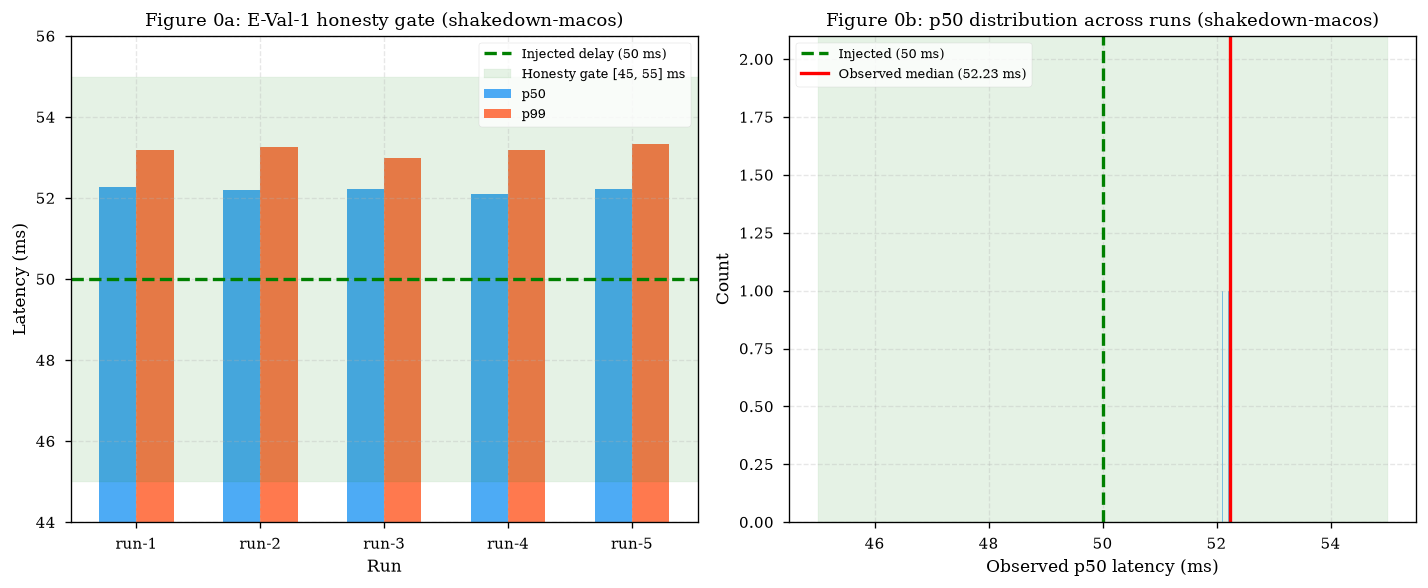

saved thesis figure to ../figures/e-val-1/warmup_validation.pdf


In [5]:
# Figure: Honesty gate visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: per-run p50 and p99 with gate window
x = np.arange(len(df))
ax1.bar(x - 0.15, df['p50_ms'], 0.3, label='p50', color='#2196F3', alpha=0.8)
ax1.bar(x + 0.15, df['p99_ms'], 0.3, label='p99', color='#FF5722', alpha=0.8)
ax1.axhline(50, color='green', linestyle='--', linewidth=2, label='Injected delay (50 ms)')
ax1.axhspan(45, 55, color='green', alpha=0.1, label='Honesty gate [45, 55] ms')
ax1.set_xlabel('Run')
ax1.set_ylabel('Latency (ms)')
ax1.set_title('Figure 0a: E-Val-1 honesty gate (shakedown-macos)')
ax1.set_xticks(x)
ax1.set_xticklabels(df['run'])
ax1.legend(loc='upper right', fontsize=8)
ax1.set_ylim(44, 56)

# Right: distribution of p50 values
ax2.hist(df['p50_ms'], bins=10, color='#2196F3', edgecolor='white', alpha=0.8)
ax2.axvline(50, color='green', linestyle='--', linewidth=2, label='Injected (50 ms)')
ax2.axvline(df['p50_ms'].median(), color='red', linestyle='-', linewidth=2, label=f'Observed median ({df["p50_ms"].median():.2f} ms)')
ax2.axvspan(45, 55, color='green', alpha=0.1)
ax2.set_xlabel('Observed p50 latency (ms)')
ax2.set_ylabel('Count')
ax2.set_title('Figure 0b: p50 distribution across runs (shakedown-macos)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()
# T9: persist thesis figure to ../figures/e-val-1/warmup_validation.{pdf,png}
_saved = save_figure(fig, 'e-val-1/warmup_validation')
print(f'saved thesis figure to {_saved}')

## Interpretation

The honesty gate PASSES on all 5 runs. The observed p50 (52.1–52.3 ms)
is consistently ~2.2 ms above the injected 50 ms, representing the fixed
overhead of the Wasm boundary + channel transit + BenchSink recording.
This overhead is small relative to the gate window (±5 ms) and stable
across runs (range <0.2 ms), confirming the measurement rig is honest.

All downstream latency measurements include this ~2 ms fixed overhead.
For experiments that compare systems (E-Perf-1/2), this overhead cancels
because all systems share the same BenchSink path. For absolute numbers
(E-Perf-4/8), the overhead is negligible relative to the measurement
scale (microseconds vs milliseconds).